In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
#load dataset
data = pd.read_csv("/content/parkinsons.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [23]:
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [24]:
#preprocess data
data.drop(['name'], axis=1, inplace=True)
data['status'] = data.status.astype(bool)


#the count of each status category
data['status'].value_counts()

,count
status,
True,147
False,48


In [25]:
data.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,True,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,True,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,True,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,True,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,True,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


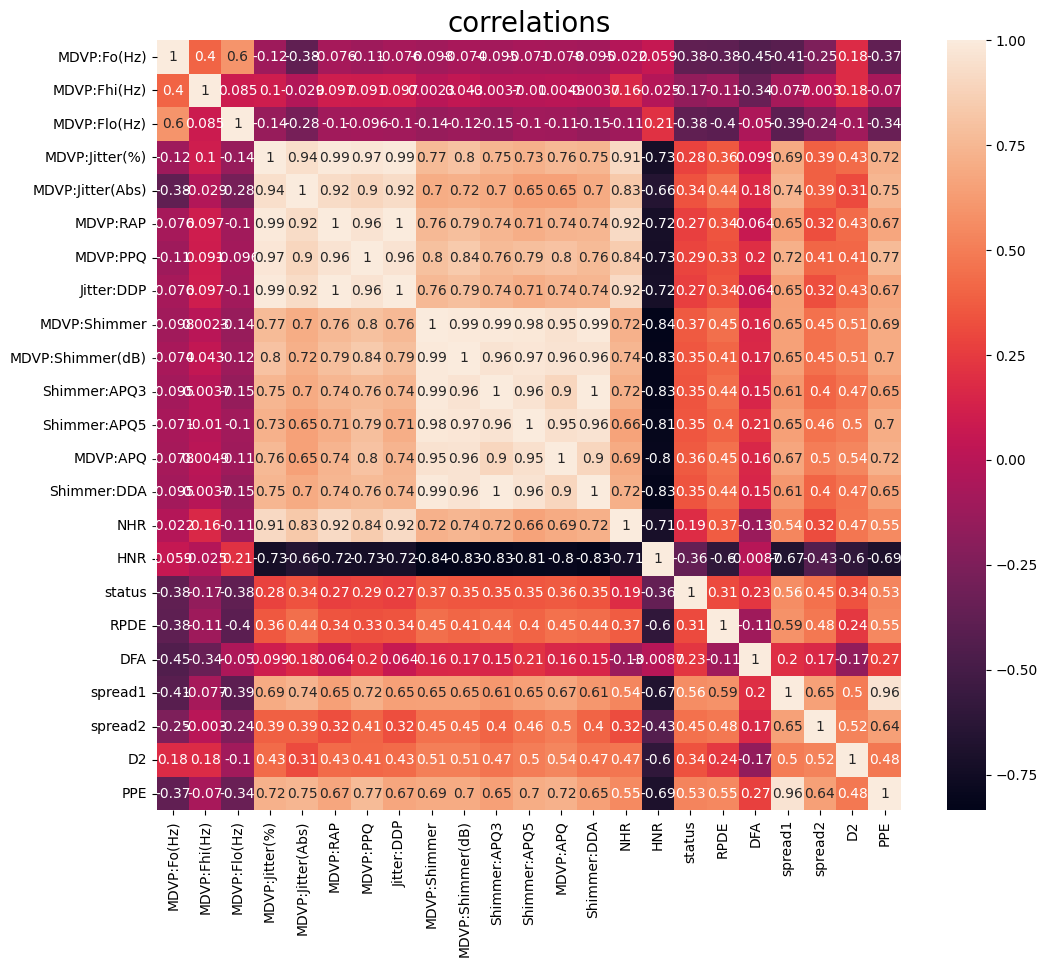

In [26]:
#correlation matrix
data.corr(numeric_only=True)['status'].abs().sort_values(ascending=False)
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True)
plt.title("correlations", size=20)
plt.show()

In [27]:
X = data.drop('status', axis=1)
y = data['status']


#standardize
scaler = StandardScaler()
scaler.fit(X)
scaler_feature = scaler.transform(X)
df_feature = pd.DataFrame(scaler_feature, columns=X.columns)

#training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_feature, y, test_size=0.33, random_state=42)

In [28]:
#best k
err_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    predi = knn.predict(X_test)
    err_rate.append(np.mean(predi != y_test))

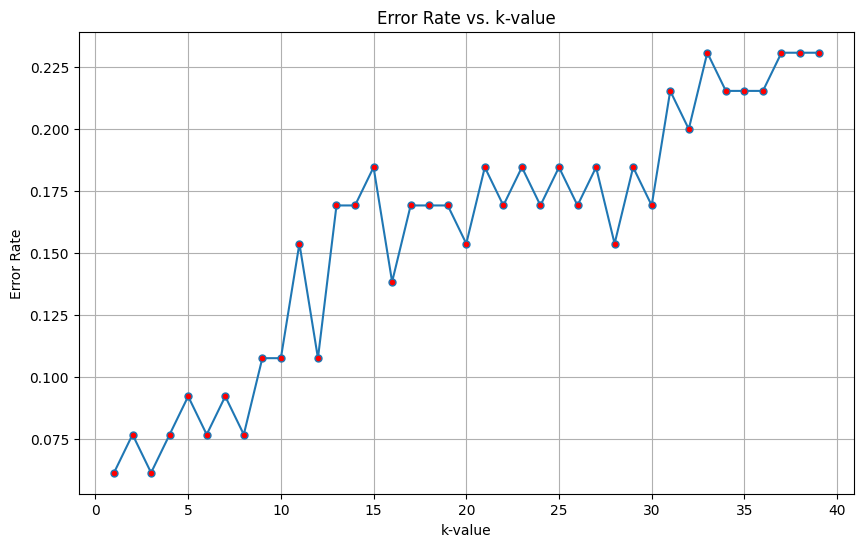

In [29]:
#plot error rate vs. k value
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(range(1, 40), err_rate, marker='.', markerfacecolor='red', markersize=10)
plt.xlabel('k-value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs. k-value')
plt.show()


In [30]:

#train k-NN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
prediction = knn.predict(X_test)

#report and confusion matrix
print('Classification report')
print(classification_report(y_test, prediction))
print('\n')
print('Confusion matrix')
print(confusion_matrix(y_test, prediction))

#the accuracy of the model
accuracy = accuracy_score(y_test, prediction) * 100
print(f'Model accuracy is: {round(accuracy, 2)} %')

Classification report
              precision    recall  f1-score   support

       False       0.88      0.88      0.88        17
        True       0.96      0.96      0.96        48

    accuracy                           0.94        65
   macro avg       0.92      0.92      0.92        65
weighted avg       0.94      0.94      0.94        65



Confusion matrix
[[15  2]
 [ 2 46]]
Model accuracy is: 93.85 %


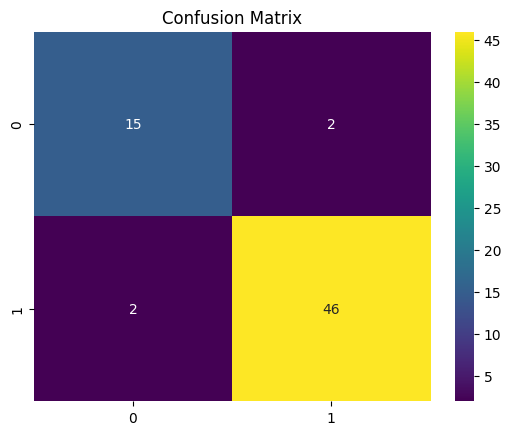

In [31]:

#plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, prediction), cmap='viridis', annot=True)
plt.title('Confusion Matrix')
plt.show()
